##Bibliotecas utilizadas

In [1]:
import sys
import numpy as np
import scipy
import cv2
import sklearn
import skimage
import tensorflow as tf
import matplotlib

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("OpenCV:", cv2.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Scikit-image:", skimage.__version__)
print("TensorFlow:", tf.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.14 (tags/v3.13.14:fd17997, Jun 10 2026, 13:03:48) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
SciPy: 1.18.0
OpenCV: 5.0.0
Scikit-learn: 1.9.0
Scikit-image: 0.26.0
TensorFlow: 2.21.0
Matplotlib: 3.11.1


In [2]:
from scipy.io import loadmat
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import metrics as metrics
import tensorflow as tf
from tensorflow.keras import backend as K
from keras import layers, Input, Model
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization, UpSampling2D

##Conjunto de dados

Acessibilidade (montagem) ao Google Drive do usuário para acessar o conjunto de dados

Obtenção dos dados (2780 imagens térmicas infravermelhas) compactadas no formato matfile (Matlab)

In [3]:
from pathlib import Path
from scipy.io import loadmat

DATASET_DIR = Path("../dataset")

mat_front = loadmat(
    DATASET_DIR / "COMP412-6_Front_Flash-000136.mat"
)

mat_back = loadmat(
    DATASET_DIR / "COMP412-6_Back_Flash-000137.mat"
)

Manipulação dos dados obtidos pelo arquivo matfile, selecionando somente as matrizes que representam cada uma das imagens (dados) do conjunto de dados

In [4]:
dataset_front = mat_front['temperature']
dataset_back = mat_back['temperature']

print(dataset_front.shape)
print(dataset_back.shape)
print(dataset_front.dtype)
print(dataset_back.dtype)

(416, 421, 1385)
(423, 419, 1395)
float32
float32


In [5]:
print(dataset_front.shape)
print(dataset_back.shape)

(416, 421, 1385)
(423, 419, 1395)


Transposição da matriz de dados para adequação e manipulação com as bibliotecas numéricas do python

In [6]:
dataset_front = np.moveaxis(dataset_front, 2, 0)
dataset_back = np.moveaxis(dataset_back, 2, 0)

In [7]:
print(dataset_front.shape)
print(dataset_back.shape)

(1385, 416, 421)
(1395, 423, 419)


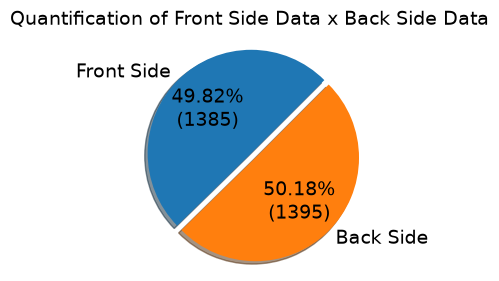

np.int64(2780)

In [8]:
def format(percent_value):
  return '{:.2f}%\n({:.0f})'.format(percent_value, pie_data.sum() * (percent_value / 100))

pie_data = np.array([len(dataset_front), len(dataset_back)])
pie_labels = ['Front Side', 'Back Side']
explode = [0.03 for x in pie_data]
fig, ax = plt.subplots()
ax.pie(pie_data, labels = pie_labels, explode = explode, autopct = format, shadow = True, startangle = 45, textprops = {'fontsize': 14})
fig.suptitle('Quantification of Front Side Data x Back Side Data', fontsize = 14)
ax.axis('equal')
fig.set_figheight(3)
fig.set_figwidth(3)
plt.show()
pie_data.sum()

Unificação das duas bases originais de dados

In [9]:
dataset = list(dataset_front) + list(dataset_back)

In [10]:
train_images, temp_images = train_test_split(
    dataset,
    train_size=0.8,
    random_state=0
)

valid_images, test_images = train_test_split(
    temp_images,
    test_size=0.5,
    random_state=0
)

Normalização dos dados

In [11]:
global_min = min(
    np.min(image)
    for image in train_images
)

global_max = max(
    np.max(image)
    for image in train_images
)

In [12]:
def normalizar_inplace(imagens, global_min, global_max):
    intervalo = np.float32(global_max - global_min)
    minimo = np.float32(global_min)

    for image in imagens:
        image -= minimo
        image /= intervalo

    return imagens


train_images = normalizar_inplace(
    train_images,
    global_min,
    global_max
)

valid_images = normalizar_inplace(
    valid_images,
    global_min,
    global_max
)

test_images = normalizar_inplace(
    test_images,
    global_min,
    global_max
)

In [13]:
print(
    "train:",
    min(np.min(img) for img in train_images),
    max(np.max(img) for img in train_images)
)

print(
    "valid:",
    min(np.min(img) for img in valid_images),
    max(np.max(img) for img in valid_images)
)

print(
    "test:",
    min(np.min(img) for img in test_images),
    max(np.max(img) for img in test_images)
)

train: 0.0 1.0
valid: 0.0055172592 0.39796573
test: 0.0028950218 0.22301514


In [14]:
def extrair_patches(
    imagens,
    patch_size=128,
    stride=128
):
    patches = []

    for image in imagens:
        altura, largura = image.shape

        for y in range(
            0,
            altura - patch_size + 1,
            stride
        ):
            for x in range(
                0,
                largura - patch_size + 1,
                stride
            ):
                patch = image[
                    y:y + patch_size,
                    x:x + patch_size
                ]

                patches.append(patch)

    return np.array(
        patches,
        dtype=np.float32
    )

In [15]:
patch_size = 128
stride = 128

x_train = extrair_patches(
    train_images,
    patch_size,
    stride
)

x_valid = extrair_patches(
    valid_images,
    patch_size,
    stride
)

x_test = extrair_patches(
    test_images,
    patch_size,
    stride
)

In [16]:
print("x_train:", x_train.shape, x_train.dtype)
print("x_valid:", x_valid.shape, x_valid.dtype)
print("x_test:", x_test.shape, x_test.dtype)

print("\nIntervalos:")
print("train:", np.min(x_train), np.max(x_train))
print("valid:", np.min(x_valid), np.max(x_valid))
print("test :", np.min(x_test), np.max(x_test))

x_train: (20016, 128, 128) float32
x_valid: (2502, 128, 128) float32
x_test: (2502, 128, 128) float32

Intervalos:
train: 0.0018435591 1.0
valid: 0.006824956 0.39796573
test : 0.004993554 0.22301514


Transformando o tipo do conjunto de dados de "python list" para o formato "ndarray (float32)" da biblioteca numpy (utilizado pelo Kernas - biblioteca Google para machine learning)

Divisão por imagem original:

In [17]:
x_train = np.expand_dims(x_train, axis=-1)
x_valid = np.expand_dims(x_valid, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("x_train:", x_train.shape)
print("x_valid:", x_valid.shape)
print("x_test:", x_test.shape)

x_train: (20016, 128, 128, 1)
x_valid: (2502, 128, 128, 1)
x_test: (2502, 128, 128, 1)


In [18]:
assert x_train.ndim == 4
assert x_valid.ndim == 4
assert x_test.ndim == 4

assert x_train.shape[-1] == 1
assert x_valid.shape[-1] == 1
assert x_test.shape[-1] == 1

Embaralhamento do conjunto de dados

Aplicação de ruído gaussiano nos subconjuntos de treino, validação e teste

In [19]:
sigma = 0.005

In [20]:
noise_train = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=x_train.shape
).astype(np.float32)

noise_valid = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=x_valid.shape
).astype(np.float32)

noise_test = np.random.normal(
    loc=0.0,
    scale=sigma,
    size=x_test.shape
).astype(np.float32)

x_train_noisy = np.clip(
    x_train + noise_train,
    0.0,
    1.0
).astype(np.float32)

x_valid_noisy = np.clip(
    x_valid + noise_valid,
    0.0,
    1.0
).astype(np.float32)

x_test_noisy = np.clip(
    x_test + noise_test,
    0.0,
    1.0
).astype(np.float32)

##Apresentação das Imagens

Exibição das 10 primeiras imagens dos seguintes conjuntos dos dados de testes:

* Original;
* Com ruído gaussiano.

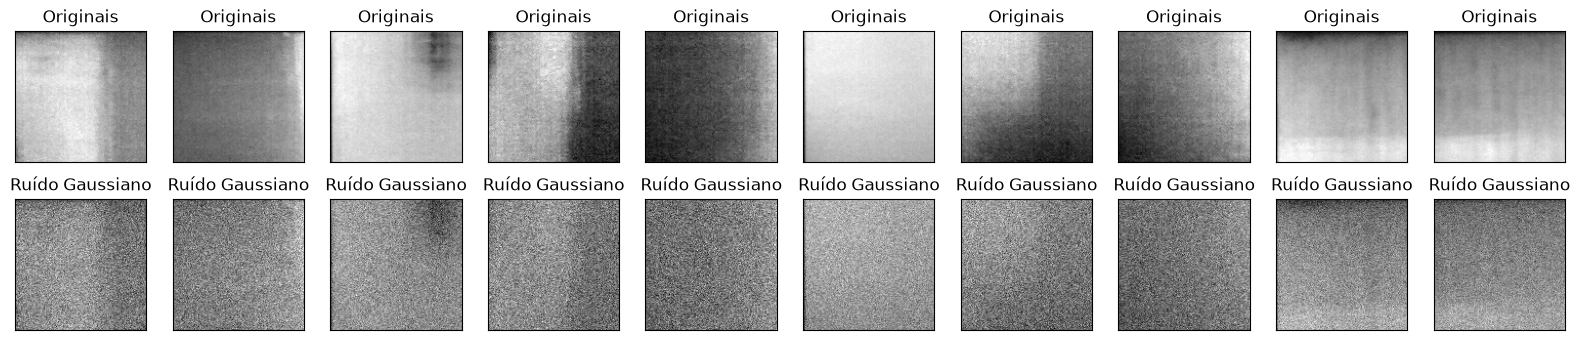

In [21]:
n = 10

plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    ax = plt.subplot(2, n, i)
    plt.title('Originais')
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + n)
    plt.title('Ruído Gaussiano')
    plt.imshow(x_test_noisy[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

##Implementação da Arquitetura do Autoencorder CNN

AutoEncoder (AE) é um tipo de Rede Neural de Aprendizagem Profunda (*Deep Learning Neural Network* - DLNN ou *Deep Neural Network* - DNN), na qual seu aprendizado é não supervisionado e sua arquitetura é fundamentada nas Redes Neurais Convolucionais (*Convolutional Neural Network* - CNN).

Essencialmente os autoencoders são segregados em três módulos principais: o Encoder, o Code, e o Decoder.

O AE's têm como objetivo aproximar a saída aos dados da entrada. Ou seja, quanto mais a saída se assemelhar com a entrada, melhor é a capacidade de reconstrução do autoencoder. Entretanto, assim como diversas outras redes, há que se atentar a questões como Overfitting.

A Figura 1 representa, diagramaticamente, a estrutura do AE e seus três pilares básicos: o Encoder, o Code e Decoder.

<figure>
<center>
<figcaption>Figura 1: visão geral da estrutura do AutoEnconder
</figcaption>
<img src='https://miro.medium.com/v2/resize:fit:720/format:webp/1*Me8UpTdSuznquyF86s9xeQ.jpeg' />
<figcaption>Fonte: https://miro.medium.com/v2/resize:fit:720/format:webp/1*Me8UpTdSuznquyF86s9xeQ.jpeg
</figcaption>
</center>
</figure>

Naturalmente não há motivos que justifique o interesse em uma rede neural que apresente, em sua saída, as suas entradas.
Porém, o aspecto de grande relevância nos AE's é a codificação dos dados da entrada pelo Encoder, ou seja, o Code.
A figura 2 ilustra um diagrama um pouco mais aprofundado e detalhado sobre a arquitetura dos AE's.

<figure>
<center>
<figcaption>Figura 2: modelo de arquitetura do AutoEnconder
</figcaption>
<img src='https://lilianweng.github.io/posts/2018-08-12-vae/denoising-autoencoder-architecture.png' />
<figcaption>Fonte: https://lilianweng.github.io/posts/2018-08-12-vae/denoising-autoencoder-architecture.png
</figcaption>
</center>
</figure>

Fontes:

* https://www.deeplearningbook.org/contents/autoencoders.html


Criação das camadas de convolucão e pooling (típicas de uma CNN clássica) com kernels 3x3, funções de ativação do tipo ReLU (Unidade Linear Retificada), mantendo as mesmas dimensões dos dados da entrada

In [22]:
inputs = tf.keras.Input(shape=(None, None, 1))

x = tf.keras.layers.Conv2D(
    64,
    3,
    padding="same",
    activation="relu"
)(inputs)

for _ in range(5):
    x = tf.keras.layers.Conv2D(
        64,
        3,
        padding="same",
        activation="relu"
    )(x)

predicted_noise = tf.keras.layers.Conv2D(
    1,
    3,
    padding="same",
    activation="linear",
    name="predicted_noise"
)(x)

restored = tf.keras.layers.Subtract(
    name="restored_image"
)([inputs, predicted_noise])

model = tf.keras.Model(
    inputs=inputs,
    outputs=restored
)

Sumário do Denoising AutoEncoder

In [23]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        640 │ input_layer[0][0] │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │     36,928 │ conv2d[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_1[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_2[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_3[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, None,      │     36,928 │ conv2d_4[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_noise     │ (None, None,      │        577 │ conv2d_5[0][0]    │
│ (Conv2D)            │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ restored_image      │ (None, None,      │          0 │ input_layer[0][0… │
│ (Subtract)          │ None, 1)          │            │ predicted_noise[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 185,857 (726.00 KB)

 Trainable params: 185,857 (726.00 KB)

 Non-trainable params: 0 (0.00 B)

Compilação da CNN (AE) com a função ADAM para a otimização e a função Binary Cross-Entropy

In [24]:
def mae_ssim_loss(y_true, y_pred):

    mae = tf.reduce_mean(
        tf.abs(y_true - y_pred)
    )

    ssim = tf.reduce_mean(
        tf.image.ssim(
            y_true,
            y_pred,
            max_val=1.0
        )
    )

    structural_loss = 1.0 - ssim

    return (
        0.8 * mae +
        0.2 * structural_loss
    )

In [25]:
model.compile(
    optimizer='adam',
    loss=mae_ssim_loss
)

Etapa de treinamento da CNN-AE utilizando os dados de treino e de testes, originais e com sintéticos ruídos gaussianos, 50 épocas, lotes (subgrupos) de tamanho 128 e que, a cada lote, os dados serão selecionados de forma aleatória e com reposição

## Recuperação do Experimento 06 após interrupção

Esta versão **não reinicia o treinamento**. Ela carrega o melhor modelo persistido em `melhor_modelo_exp06.keras` e segue diretamente para inferência, métricas e visualização.

O backup em `backup_treinamento_exp06/` é preservado e não é alterado por este notebook.


In [26]:
from pathlib import Path

MODEL_PATH = Path("melhor_modelo_exp06.keras")
BACKUP_DIR = Path("backup_treinamento_exp06")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modelo não encontrado: {MODEL_PATH.resolve()}"
    )

print(f"Modelo encontrado: {MODEL_PATH.resolve()}")
print(f"Backup de treinamento presente: {BACKUP_DIR.exists()}")

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "mae_ssim_loss": mae_ssim_loss
    }
)

print("\nMelhor modelo do Experimento 06 carregado com sucesso.")
print("Nenhum treinamento foi reiniciado nesta versão do notebook.")


Modelo encontrado: C:\Doutorado\termografia\notebooks\melhor_modelo_exp06.keras
Backup de treinamento presente: False

Melhor modelo do Experimento 06 carregado com sucesso.
Nenhum treinamento foi reiniciado nesta versão do notebook.


## Avaliação do modelo recuperado

A partir deste ponto, o notebook **não realiza novo treinamento**. O melhor modelo salvo no
Experimento 06 é avaliado na condição de treinamento (`σ = 0.0025`) e, em seguida, é submetido
a diferentes intensidades de ruído para análise de robustez.


In [27]:
import pandas as pd

SIGMA_TREINO = 0.0025
BATCH_SIZE = 128
SEMENTE = 0

# Ruído de validação reproduzível, na mesma intensidade usada no treinamento do Exp. 06.
rng_valid = np.random.default_rng(SEMENTE)

noise_valid = rng_valid.normal(
    loc=0.0,
    scale=SIGMA_TREINO,
    size=x_valid.shape
).astype(np.float32)

x_valid_noisy = np.clip(
    x_valid + noise_valid,
    0.0,
    1.0
).astype(np.float32)

print("Sigma de treinamento:", SIGMA_TREINO)
print("x_valid_noisy:", x_valid_noisy.shape, x_valid_noisy.dtype)


Sigma de treinamento: 0.0025
x_valid_noisy: (2502, 128, 128, 1) float32


In [28]:
# Verificação rápida do modelo recuperado
print("Entrada esperada:", model.input_shape)
print("Saída esperada:", model.output_shape)

val_loss_recuperada = model.evaluate(
    x_valid_noisy,
    x_valid,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"\nLoss de validação do modelo recuperado: {val_loss_recuperada:.8e}")


Entrada esperada: (None, None, None, 1)
Saída esperada: (None, None, None, 1)
20/20 ━━━━━━━━━━━━━━━━━━━━ 95s 5s/step - loss: 4.4119e-04

Loss de validação do modelo recuperado: 4.41191543e-04


## Funções auxiliares

As funções abaixo separam três responsabilidades:

1. geração da imagem ruidosa e inferência;
2. cálculo das métricas;
3. organização dos resultados para cada valor de `σ`.


In [29]:
from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)

def avaliar_sigma(
    model,
    x_original,
    noise_base,
    sigma,
    batch_size=128
):
    """Gera a entrada ruidosa para um sigma e executa a restauração."""

    noise = noise_base * np.float32(sigma)

    x_noisy = np.clip(
        x_original + noise,
        0.0,
        1.0
    ).astype(np.float32)

    x_restored = model.predict(
        x_noisy,
        batch_size=batch_size,
        verbose=0
    )

    x_restored = np.clip(
        x_restored,
        0.0,
        1.0
    ).astype(np.float32)

    return x_noisy, x_restored


def calcular_metricas(
    x_original,
    x_noisy,
    x_restored
):
    """Calcula as métricas médias para um conjunto de imagens."""

    psnr_noisy = []
    psnr_restored = []

    ssim_noisy = []
    ssim_restored = []

    rmse_noisy = []
    rmse_restored = []

    mae_noisy = []
    mae_restored = []

    for original, noisy, restored in zip(
        x_original,
        x_noisy,
        x_restored
    ):
        original = np.squeeze(original)
        noisy = np.squeeze(noisy)
        restored = np.squeeze(restored)

        psnr_noisy.append(
            peak_signal_noise_ratio(
                original,
                noisy,
                data_range=1.0
            )
        )

        psnr_restored.append(
            peak_signal_noise_ratio(
                original,
                restored,
                data_range=1.0
            )
        )

        ssim_noisy.append(
            structural_similarity(
                original,
                noisy,
                data_range=1.0
            )
        )

        ssim_restored.append(
            structural_similarity(
                original,
                restored,
                data_range=1.0
            )
        )

        rmse_noisy.append(
            np.sqrt(
                np.mean((original - noisy) ** 2)
            )
        )

        rmse_restored.append(
            np.sqrt(
                np.mean((original - restored) ** 2)
            )
        )

        mae_noisy.append(
            np.mean(
                np.abs(original - noisy)
            )
        )

        mae_restored.append(
            np.mean(
                np.abs(original - restored)
            )
        )

    return {
        "PSNR_Ruidosa": float(np.mean(psnr_noisy)),
        "PSNR_Restaurada": float(np.mean(psnr_restored)),
        "SSIM_Ruidosa": float(np.mean(ssim_noisy)),
        "SSIM_Restaurada": float(np.mean(ssim_restored)),
        "RMSE_Ruidosa": float(np.mean(rmse_noisy)),
        "RMSE_Restaurada": float(np.mean(rmse_restored)),
        "MAE_Ruidosa": float(np.mean(mae_noisy)),
        "MAE_Restaurada": float(np.mean(mae_restored))
    }


## Análise de robustez para diferentes valores de σ

O modelo foi treinado com `σ = 0.0025`. Nesta etapa ele **não é retreinado**.
O mesmo modelo é testado com diferentes intensidades de ruído.

Para tornar a comparação mais controlada, usa-se o mesmo padrão de ruído normal padrão
para todos os casos, variando apenas sua amplitude por meio de `σ`.


In [30]:
sigmas = [0.001, 0.0025, 0.005, 0.010]

rng_test = np.random.default_rng(SEMENTE)

noise_base = rng_test.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
).astype(np.float32)

resultados = []
resultados_imagens = {}

for sigma_teste in sigmas:

    print(f"\n--- Sigma = {sigma_teste} ---")

    x_noisy, x_restored = avaliar_sigma(
        model=model,
        x_original=x_test,
        noise_base=noise_base,
        sigma=sigma_teste,
        batch_size=BATCH_SIZE
    )

    metricas = calcular_metricas(
        x_original=x_test,
        x_noisy=x_noisy,
        x_restored=x_restored
    )

    resultados.append({
        "sigma": sigma_teste,
        **metricas
    })

    resultados_imagens[sigma_teste] = {
        "noisy": x_noisy,
        "restored": x_restored
    }

df_resultados = pd.DataFrame(resultados)

df_resultados



--- Sigma = 0.001 ---

--- Sigma = 0.0025 ---

--- Sigma = 0.005 ---

--- Sigma = 0.01 ---


,sigma,PSNR_Ruidosa,PSNR_Restaurada,SSIM_Ruidosa,SSIM_Restaurada,RMSE_Ruidosa,RMSE_Restaurada,MAE_Ruidosa,MAE_Restaurada
0,0.0010,60.000650,65.298631,0.998886,0.999692,0.001000,0.000544,0.000798,0.000426
1,0.0025,52.041850,64.405072,0.993082,0.999652,0.002500,0.000604,0.001994,0.000474
2,0.0050,46.021267,60.959286,0.972908,0.999326,0.005000,0.000897,0.003989,0.000690
3,0.0100,40.002543,49.675477,0.900038,0.989276,0.009997,0.003284,0.007977,0.002422


## Tabela consolidada das métricas


In [31]:
df_formatado = df_resultados.copy()

for coluna in [
    "PSNR_Ruidosa",
    "PSNR_Restaurada"
]:
    df_formatado[coluna] = df_formatado[coluna].map(
        lambda v: f"{v:.4f}"
    )

for coluna in [
    "SSIM_Ruidosa",
    "SSIM_Restaurada"
]:
    df_formatado[coluna] = df_formatado[coluna].map(
        lambda v: f"{v:.6f}"
    )

for coluna in [
    "RMSE_Ruidosa",
    "RMSE_Restaurada",
    "MAE_Ruidosa",
    "MAE_Restaurada"
]:
    df_formatado[coluna] = df_formatado[coluna].map(
        lambda v: f"{v:.6f}"
    )

df_formatado


,sigma,PSNR_Ruidosa,PSNR_Restaurada,SSIM_Ruidosa,SSIM_Restaurada,RMSE_Ruidosa,RMSE_Restaurada,MAE_Ruidosa,MAE_Restaurada
0,0.0010,60.0006,65.2986,0.998886,0.999692,0.001000,0.000544,0.000798,0.000426
1,0.0025,52.0419,64.4051,0.993082,0.999652,0.002500,0.000604,0.001994,0.000474
2,0.0050,46.0213,60.9593,0.972908,0.999326,0.005000,0.000897,0.003989,0.000690
3,0.0100,40.0025,49.6755,0.900038,0.989276,0.009997,0.003284,0.007977,0.002422


## Ganhos obtidos após a restauração

Além dos valores absolutos das métricas, esta etapa quantifica diretamente o ganho produzido
pelo modelo em cada intensidade de ruído. Para PSNR e SSIM é calculada a diferença entre a
imagem restaurada e a imagem ruidosa. Para RMSE e MAE é calculada a redução percentual do erro.


In [32]:
df_ganhos = df_resultados.copy()

df_ganhos["Delta_PSNR"] = (
    df_ganhos["PSNR_Restaurada"]
    - df_ganhos["PSNR_Ruidosa"]
)

df_ganhos["Delta_SSIM"] = (
    df_ganhos["SSIM_Restaurada"]
    - df_ganhos["SSIM_Ruidosa"]
)

df_ganhos["Reducao_RMSE_percentual"] = (
    (
        df_ganhos["RMSE_Ruidosa"]
        - df_ganhos["RMSE_Restaurada"]
    )
    / df_ganhos["RMSE_Ruidosa"]
) * 100.0

df_ganhos["Reducao_MAE_percentual"] = (
    (
        df_ganhos["MAE_Ruidosa"]
        - df_ganhos["MAE_Restaurada"]
    )
    / df_ganhos["MAE_Ruidosa"]
) * 100.0

df_ganhos_formatado = df_ganhos[
    [
        "sigma",
        "Delta_PSNR",
        "Delta_SSIM",
        "Reducao_RMSE_percentual",
        "Reducao_MAE_percentual"
    ]
].copy()

df_ganhos_formatado["Delta_PSNR"] = (
    df_ganhos_formatado["Delta_PSNR"]
    .map(lambda x: f"{x:+.4f} dB")
)

df_ganhos_formatado["Delta_SSIM"] = (
    df_ganhos_formatado["Delta_SSIM"]
    .map(lambda x: f"{x:+.6f}")
)

df_ganhos_formatado["Reducao_RMSE_percentual"] = (
    df_ganhos_formatado["Reducao_RMSE_percentual"]
    .map(lambda x: f"{x:.2f}%")
)

df_ganhos_formatado["Reducao_MAE_percentual"] = (
    df_ganhos_formatado["Reducao_MAE_percentual"]
    .map(lambda x: f"{x:.2f}%")
)

df_ganhos_formatado


,sigma,Delta_PSNR,Delta_SSIM,Reducao_RMSE_percentual,Reducao_MAE_percentual
0,0.0010,+5.2980 dB,+0.000806,45.55%,46.66%
1,0.0025,+12.3632 dB,+0.006571,75.86%,76.26%
2,0.0050,+14.9380 dB,+0.026418,82.05%,82.69%
3,0.0100,+9.6729 dB,+0.089237,67.15%,69.64%


## Curvas dos ganhos de restauração

Os gráficos seguintes mostram o ganho de PSNR e a redução percentual de RMSE e MAE.
Eles complementam as curvas de robustez apresentadas na seção seguinte, evidenciando
quanto o modelo melhora cada condição de entrada.


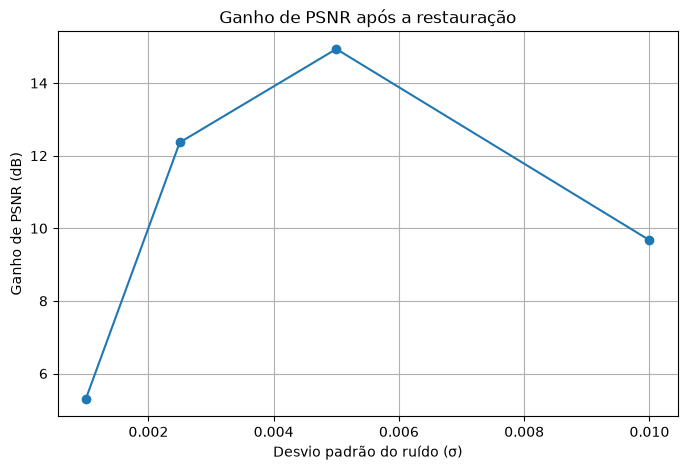

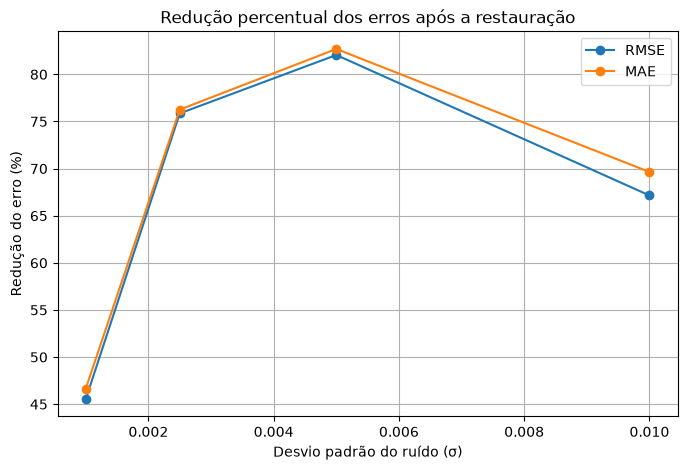

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    df_ganhos["sigma"],
    df_ganhos["Delta_PSNR"],
    marker="o"
)

plt.xlabel("Desvio padrão do ruído (σ)")
plt.ylabel("Ganho de PSNR (dB)")
plt.title("Ganho de PSNR após a restauração")
plt.grid(True)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    df_ganhos["sigma"],
    df_ganhos["Reducao_RMSE_percentual"],
    marker="o",
    label="RMSE"
)

plt.plot(
    df_ganhos["sigma"],
    df_ganhos["Reducao_MAE_percentual"],
    marker="o",
    label="MAE"
)

plt.xlabel("Desvio padrão do ruído (σ)")
plt.ylabel("Redução do erro (%)")
plt.title("Redução percentual dos erros após a restauração")
plt.legend()
plt.grid(True)
plt.show()


## Curvas de robustez

Cada gráfico compara a imagem ruidosa com a imagem restaurada pelo mesmo modelo
à medida que a intensidade do ruído aumenta.


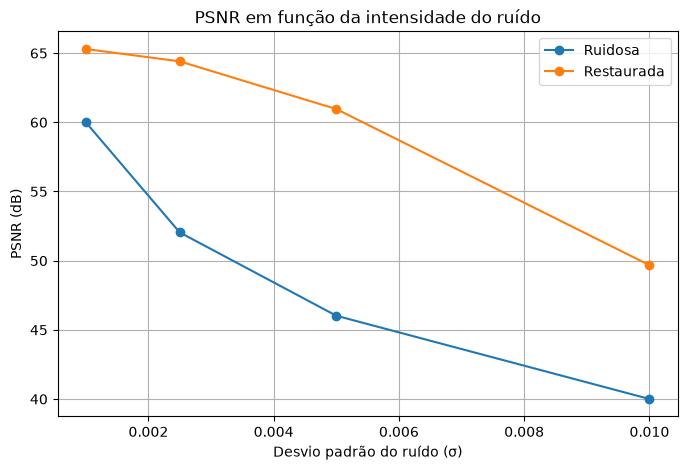

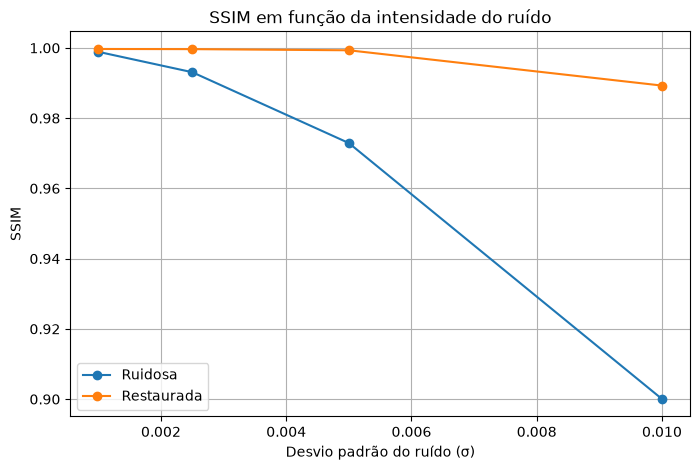

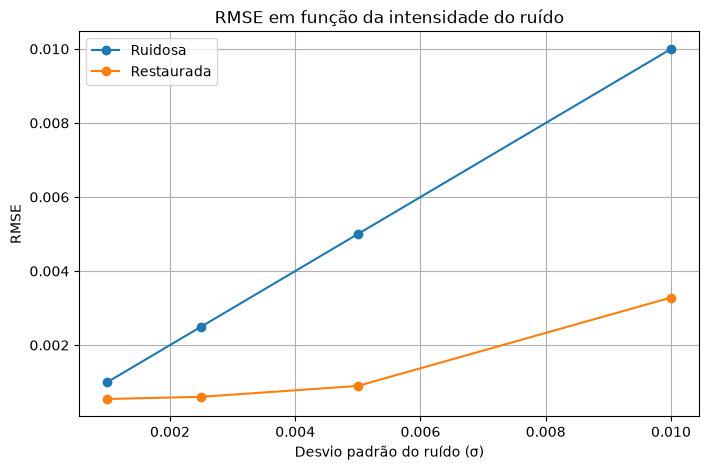

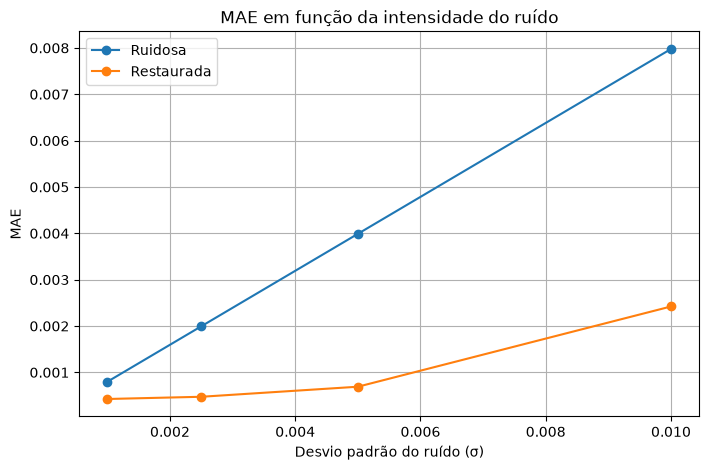

In [34]:
def plotar_metrica(
    df,
    coluna_ruidosa,
    coluna_restaurada,
    ylabel,
    titulo
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        df["sigma"],
        df[coluna_ruidosa],
        marker="o",
        label="Ruidosa"
    )

    plt.plot(
        df["sigma"],
        df[coluna_restaurada],
        marker="o",
        label="Restaurada"
    )

    plt.xlabel("Desvio padrão do ruído (σ)")
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()


plotar_metrica(
    df_resultados,
    "PSNR_Ruidosa",
    "PSNR_Restaurada",
    "PSNR (dB)",
    "PSNR em função da intensidade do ruído"
)

plotar_metrica(
    df_resultados,
    "SSIM_Ruidosa",
    "SSIM_Restaurada",
    "SSIM",
    "SSIM em função da intensidade do ruído"
)

plotar_metrica(
    df_resultados,
    "RMSE_Ruidosa",
    "RMSE_Restaurada",
    "RMSE",
    "RMSE em função da intensidade do ruído"
)

plotar_metrica(
    df_resultados,
    "MAE_Ruidosa",
    "MAE_Restaurada",
    "MAE",
    "MAE em função da intensidade do ruído"
)


## Comparação visual para a mesma imagem em todos os níveis de ruído

A mesma imagem do conjunto de teste é utilizada em todos os casos.
A janela de visualização é definida a partir da imagem original e mantida constante,
evitando que ajustes independentes de contraste influenciem a comparação.


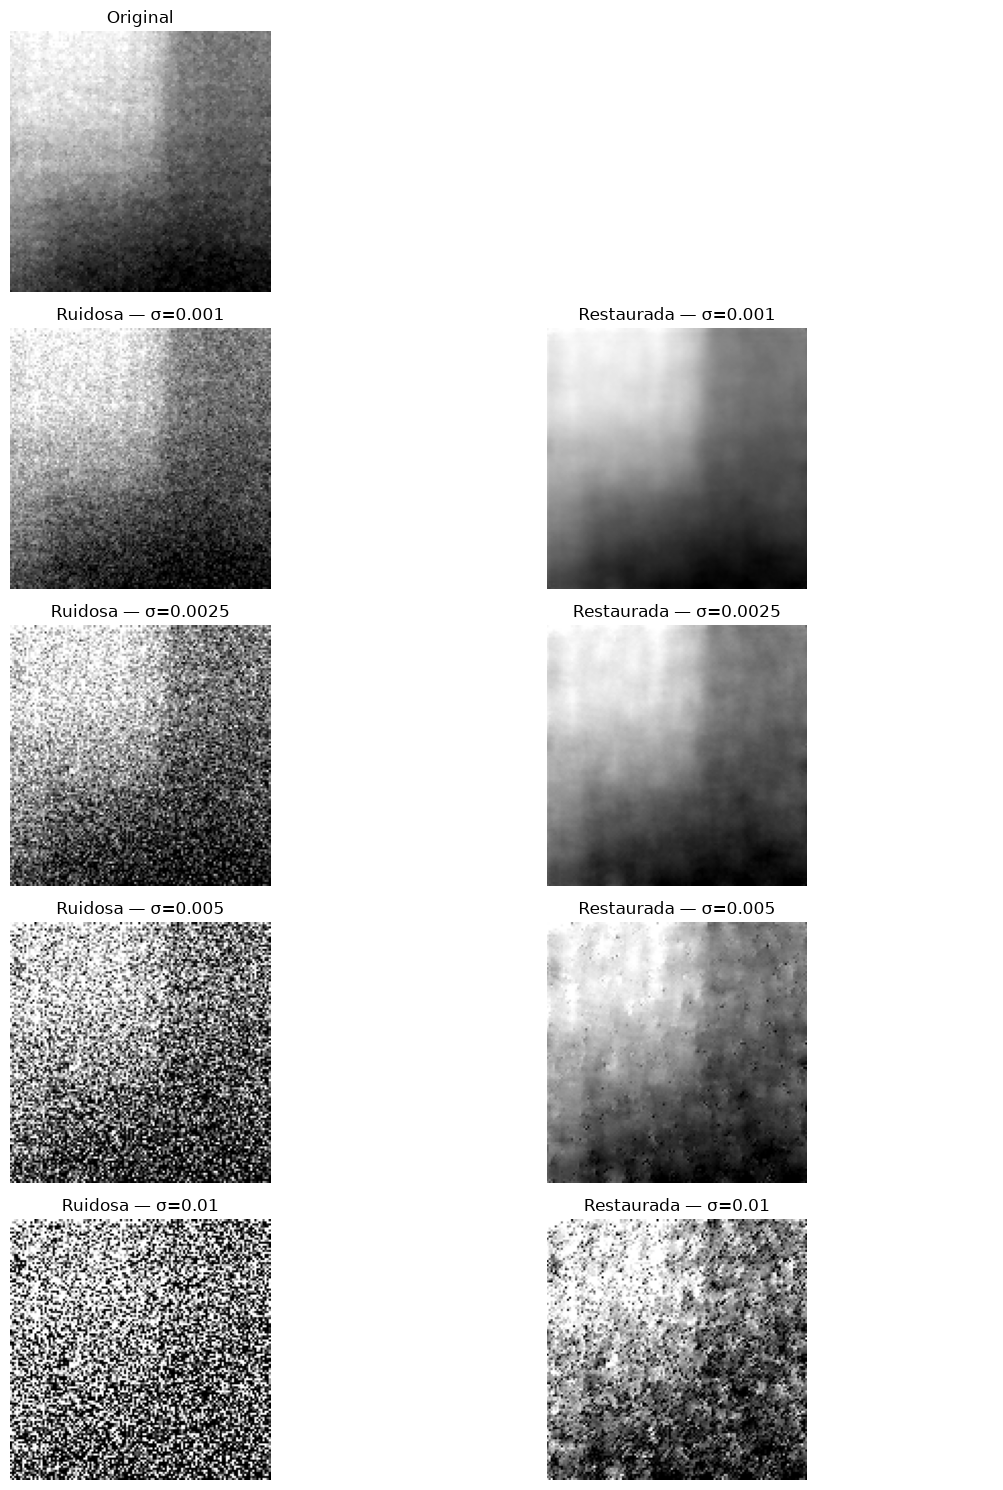

In [35]:
idx = 43

original = np.squeeze(x_test[idx])

vmin = np.percentile(original, 1)
vmax = np.percentile(original, 99)

linhas = len(sigmas) + 1

plt.figure(figsize=(12, 3 * linhas))

# Imagem original
ax = plt.subplot(linhas, 2, 1)
plt.imshow(
    original,
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
plt.title("Original")
ax.axis("off")

# Segunda posição da primeira linha fica vazia
ax = plt.subplot(linhas, 2, 2)
ax.axis("off")

for linha, sigma_teste in enumerate(
    sigmas,
    start=1
):
    noisy = np.squeeze(
        resultados_imagens[sigma_teste]["noisy"][idx]
    )

    restored = np.squeeze(
        resultados_imagens[sigma_teste]["restored"][idx]
    )

    ax = plt.subplot(
        linhas,
        2,
        linha * 2 + 1
    )
    plt.imshow(
        noisy,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    plt.title(
        f"Ruidosa — σ={sigma_teste}"
    )
    ax.axis("off")

    ax = plt.subplot(
        linhas,
        2,
        linha * 2 + 2
    )
    plt.imshow(
        restored,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )
    plt.title(
        f"Restaurada — σ={sigma_teste}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## Comparação visual de 10 imagens para cada σ

Esta célula permite inspecionar uma amostra maior do conjunto de teste.
Para cada valor de `σ`, são apresentadas as mesmas 10 imagens originais,
suas versões ruidosas e as respectivas restaurações.


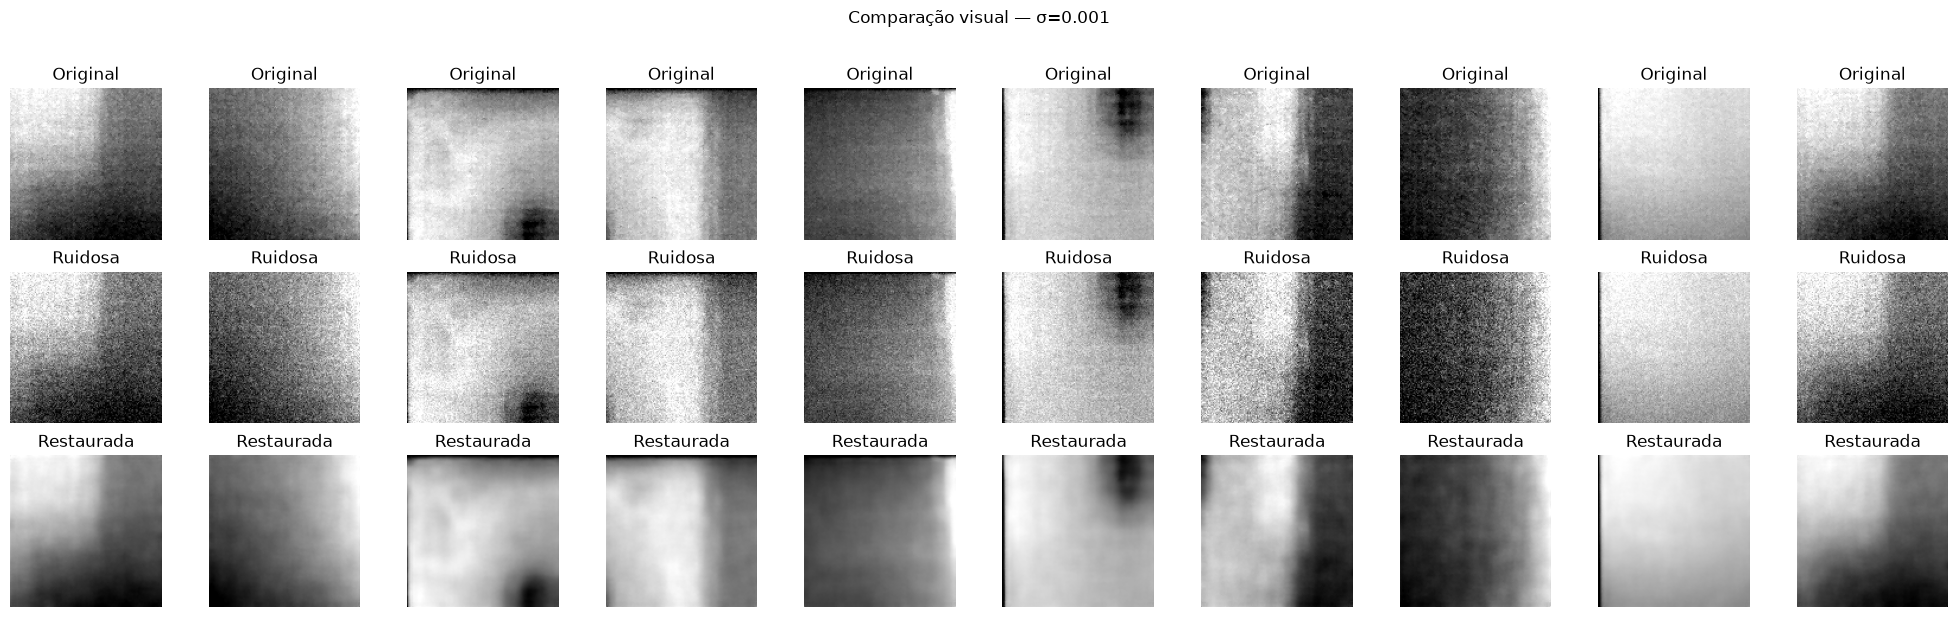

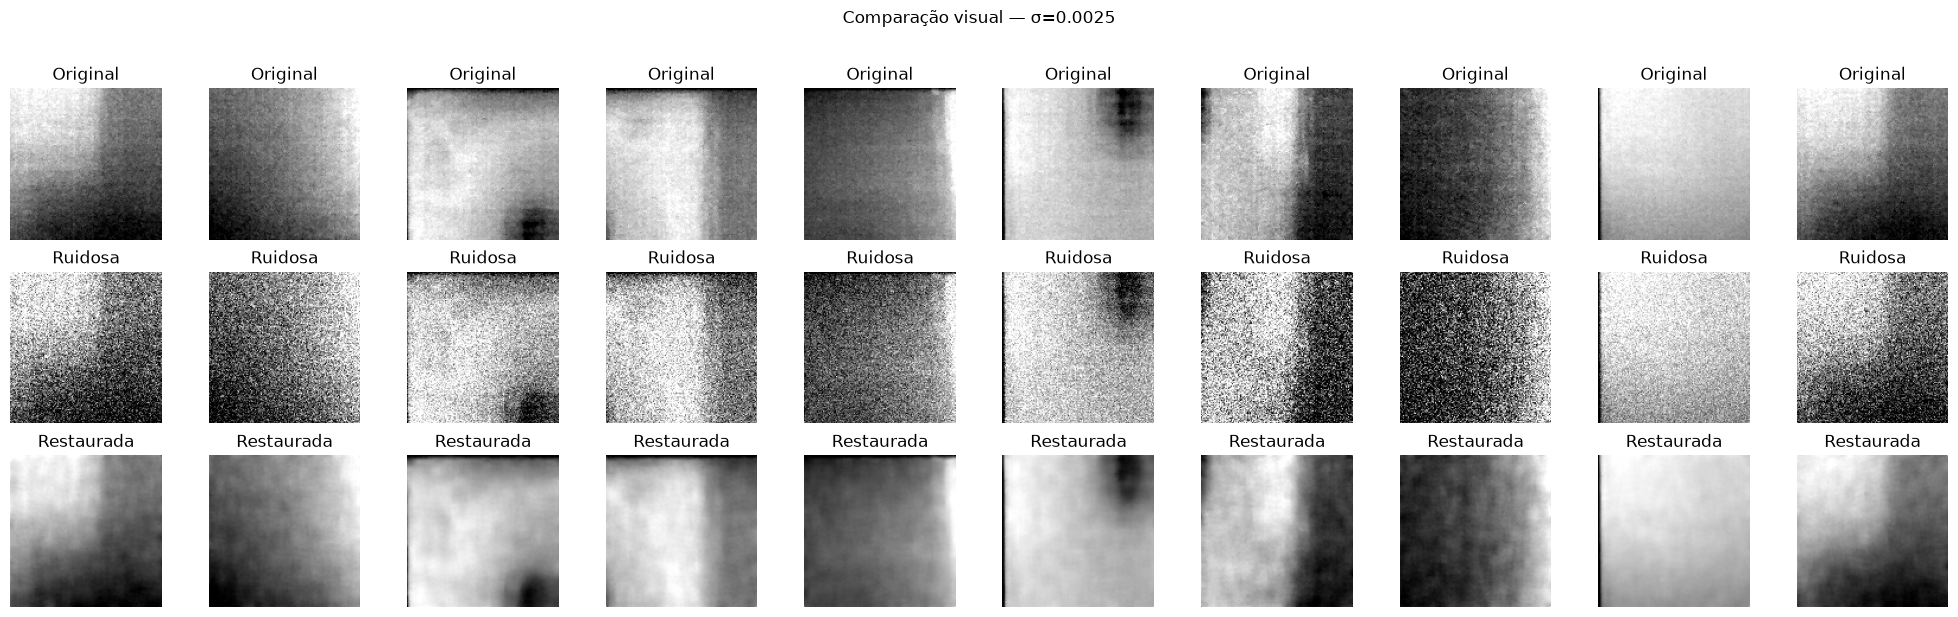

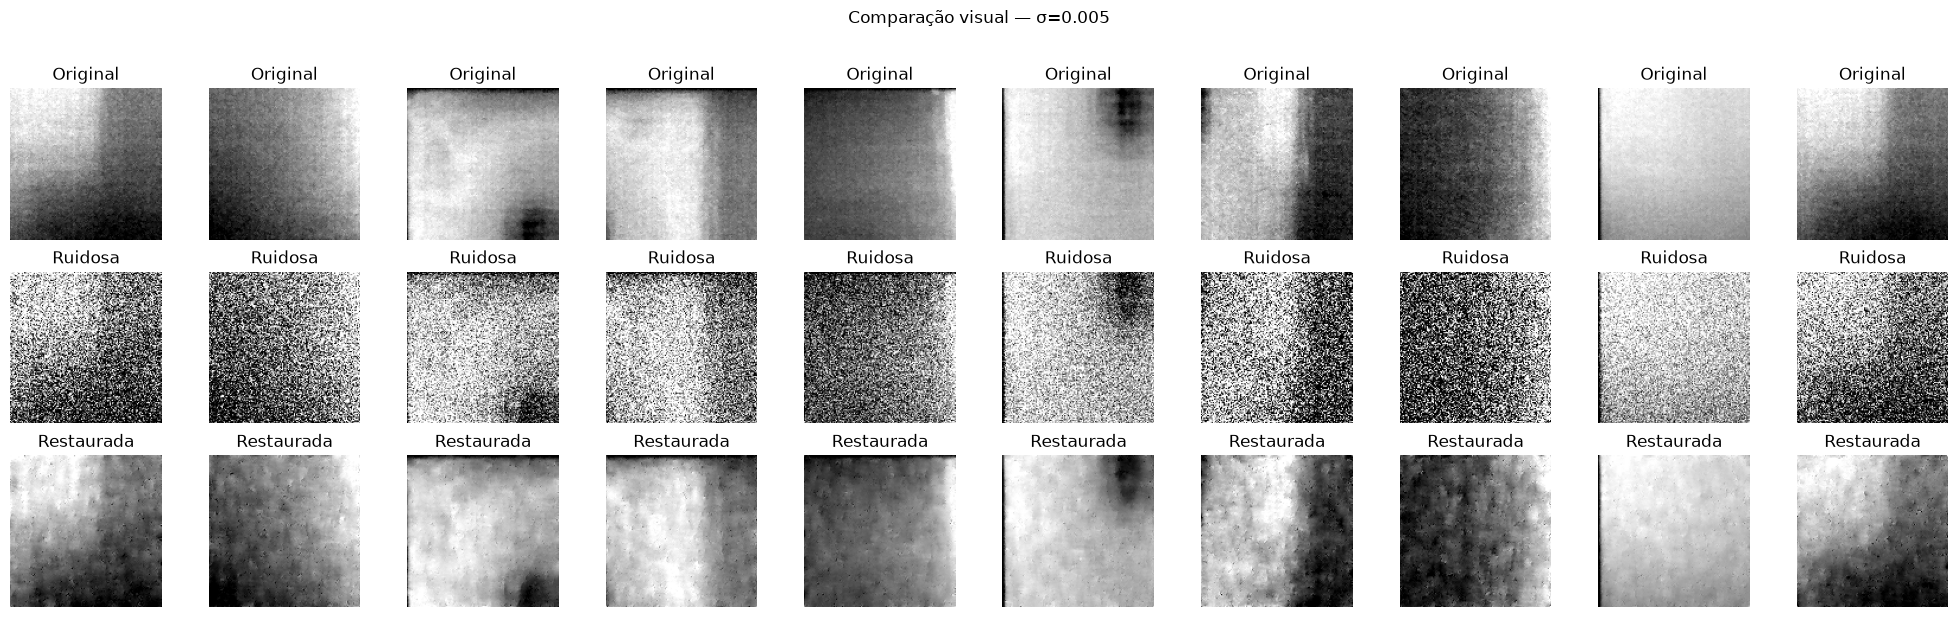

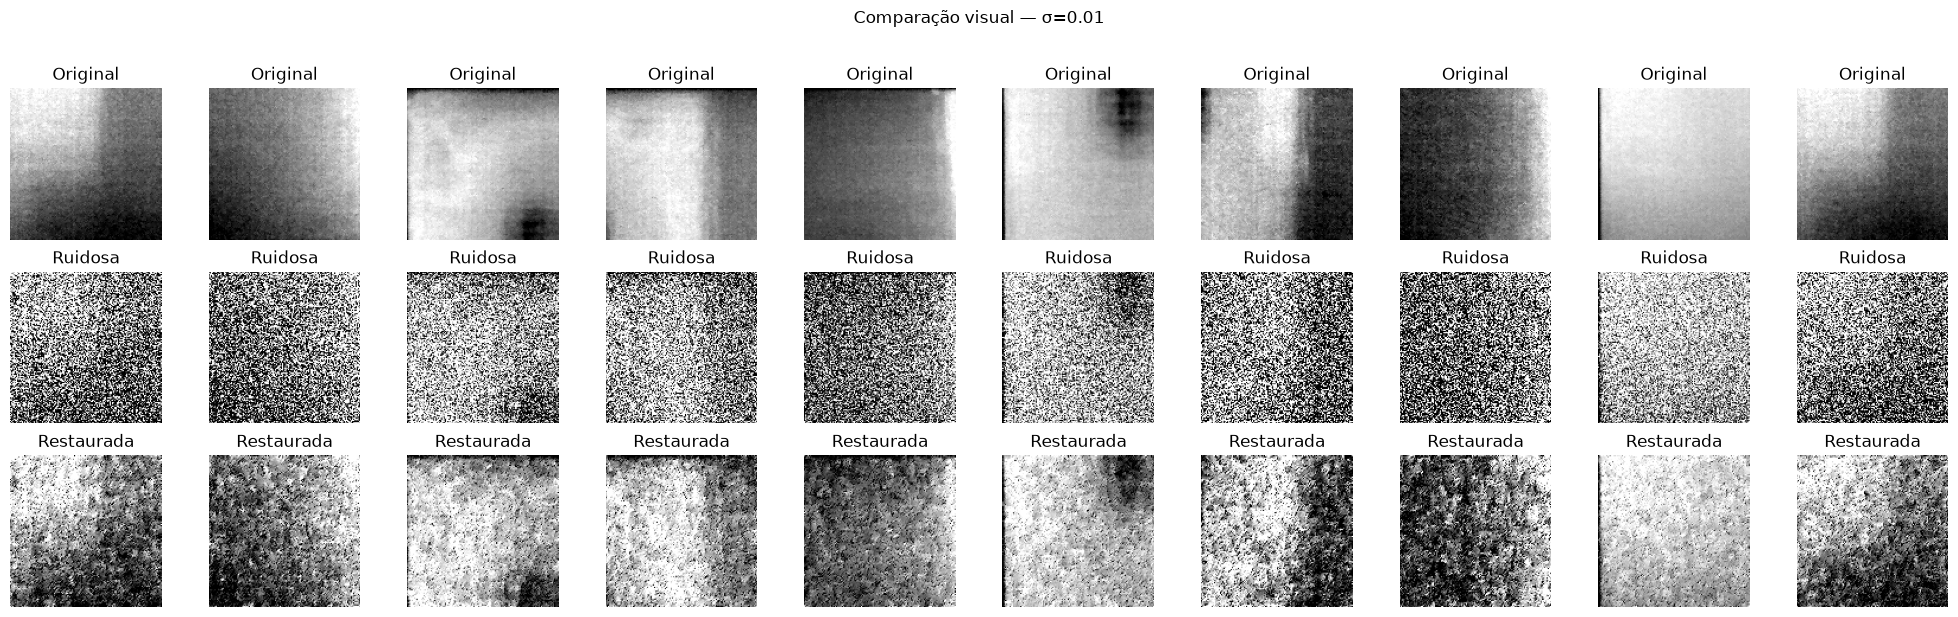

In [36]:
n = 10
indice_inicial = 43

for sigma_teste in sigmas:

    plt.figure(figsize=(20, 6))

    for i in range(n):
        idx = indice_inicial + i

        original = np.squeeze(
            x_test[idx]
        )

        noisy = np.squeeze(
            resultados_imagens[sigma_teste]["noisy"][idx]
        )

        restored = np.squeeze(
            resultados_imagens[sigma_teste]["restored"][idx]
        )

        vmin = np.percentile(original, 1)
        vmax = np.percentile(original, 99)

        ax = plt.subplot(
            3,
            n,
            i + 1
        )
        plt.imshow(
            original,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )
        plt.title("Original")
        ax.axis("off")

        ax = plt.subplot(
            3,
            n,
            i + 1 + n
        )
        plt.imshow(
            noisy,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )
        plt.title("Ruidosa")
        ax.axis("off")

        ax = plt.subplot(
            3,
            n,
            i + 1 + 2 * n
        )
        plt.imshow(
            restored,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )
        plt.title("Restaurada")
        ax.axis("off")

    plt.suptitle(
        f"Comparação visual — σ={sigma_teste}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# Comparação de qualidade — TFLite FP32 × TFLite FP16

Esta etapa avalia se a redução da precisão dos pesos para FP16 altera a qualidade da
restauração. Para preservar a comparabilidade experimental, o modelo FP16 recebe
**exatamente as mesmas imagens ruidosas** já utilizadas na análise FP32 para cada valor de `σ`.

O modelo FP16 é executado no computador. A portabilidade PC → Raspberry Pi Zero 2 W
já foi validada separadamente por comparação numérica da mesma entrada e do mesmo
artefato TFLite.


In [37]:
from pathlib import Path
import gc

TFLITE_FP16_PATH = Path("melhor_modelo_exp06_fp16.tflite")
BATCH_SIZE_TFLITE = 32

if not TFLITE_FP16_PATH.exists():
    raise FileNotFoundError(
        f"Modelo FP16 não encontrado: {TFLITE_FP16_PATH.resolve()}"
    )

print("Modelo FP16:", TFLITE_FP16_PATH.resolve())
print("Batch size TFLite:", BATCH_SIZE_TFLITE)


Modelo FP16: C:\Doutorado\termografia\notebooks\melhor_modelo_exp06_fp16.tflite
Batch size TFLite: 32


## Inferência TFLite FP16 em lotes

A função abaixo mantém um único interpretador TFLite e processa o conjunto de teste
em pequenos lotes. O tamanho do lote foi mantido conservador para reduzir o pico de
memória durante a avaliação.


In [38]:
def inferir_tflite_em_lotes(
    interpreter,
    dados,
    batch_size=32
):
    saidas = []
    shape_alocado = None

    total = len(dados)

    for inicio in range(0, total, batch_size):
        fim = min(
            inicio + batch_size,
            total
        )

        lote = dados[inicio:fim].astype(
            np.float32,
            copy=False
        )

        if shape_alocado != lote.shape:
            input_details = interpreter.get_input_details()

            interpreter.resize_tensor_input(
                input_details[0]["index"],
                lote.shape,
                strict=False
            )

            interpreter.allocate_tensors()

            shape_alocado = lote.shape

        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        interpreter.set_tensor(
            input_details[0]["index"],
            lote
        )

        interpreter.invoke()

        saida = interpreter.get_tensor(
            output_details[0]["index"]
        ).copy()

        saidas.append(saida)

    return np.concatenate(
        saidas,
        axis=0
    ).astype(np.float32)


## Avaliação FP16 nos mesmos níveis de ruído

Para cada valor de `σ`, a entrada ruidosa é recuperada diretamente de
`resultados_imagens`, produzido na avaliação FP32. Assim, FP32 e FP16 recebem
literalmente os mesmos pixels de entrada.

Para economizar memória, o notebook não mantém em RAM todas as saídas FP16 completas:
apenas uma imagem representativa de cada `σ` é preservada para comparação visual.


In [39]:
interpreter_fp16 = tf.lite.Interpreter(
    model_path=str(TFLITE_FP16_PATH)
)

resultados_fp16 = []
comparacao_saidas = []
amostras_fp16 = {}

INDICE_VISUAL = 43

for sigma_teste in sigmas:

    print(
        f"\n--- FP16 | Sigma = {sigma_teste} ---",
        flush=True
    )

    # Exatamente a mesma entrada ruidosa usada no FP32.
    x_noisy = resultados_imagens[
        sigma_teste
    ]["noisy"]

    x_restored_fp16 = inferir_tflite_em_lotes(
        interpreter=interpreter_fp16,
        dados=x_noisy,
        batch_size=BATCH_SIZE_TFLITE
    )

    x_restored_fp16 = np.clip(
        x_restored_fp16,
        0.0,
        1.0
    ).astype(np.float32)

    metricas_fp16 = calcular_metricas(
        x_original=x_test,
        x_noisy=x_noisy,
        x_restored=x_restored_fp16
    )

    resultados_fp16.append({
        "sigma": sigma_teste,
        **metricas_fp16
    })

    # Diferença direta entre as imagens restauradas FP32 e FP16.
    x_restored_fp32 = resultados_imagens[
        sigma_teste
    ]["restored"]

    diferenca = (
        x_restored_fp16.astype(np.float64)
        - x_restored_fp32.astype(np.float64)
    )

    abs_diff = np.abs(diferenca)

    comparacao_saidas.append({
        "sigma": sigma_teste,
        "MaxAbs_FP16_menos_FP32": float(
            np.max(abs_diff)
        ),
        "MeanAbs_FP16_menos_FP32": float(
            np.mean(abs_diff)
        ),
        "RMSE_FP16_menos_FP32": float(
            np.sqrt(
                np.mean(diferenca ** 2)
            )
        )
    })

    amostras_fp16[sigma_teste] = (
        x_restored_fp16[INDICE_VISUAL].copy()
    )

    del x_restored_fp16
    del diferenca
    del abs_diff

    gc.collect()

    print("Concluído.", flush=True)

df_resultados_fp16 = pd.DataFrame(
    resultados_fp16
)

df_comparacao_saidas = pd.DataFrame(
    comparacao_saidas
)

df_resultados_fp16



--- FP16 | Sigma = 0.001 ---


c:\Doutorado\termografia\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Concluído.

--- FP16 | Sigma = 0.0025 ---
Concluído.

--- FP16 | Sigma = 0.005 ---
Concluído.

--- FP16 | Sigma = 0.01 ---
Concluído.


,sigma,PSNR_Ruidosa,PSNR_Restaurada,SSIM_Ruidosa,SSIM_Restaurada,RMSE_Ruidosa,RMSE_Restaurada,MAE_Ruidosa,MAE_Restaurada
0,0.0010,60.000650,65.299231,0.998886,0.999692,0.001000,0.000544,0.000798,0.000426
1,0.0025,52.041850,64.405620,0.993082,0.999652,0.002500,0.000603,0.001994,0.000474
2,0.0050,46.021267,60.960201,0.972908,0.999326,0.005000,0.000897,0.003989,0.000690
3,0.0100,40.002543,49.676024,0.900038,0.989277,0.009997,0.003284,0.007977,0.002422


## Tabela FP32 × FP16

As colunas `Delta_*` representam `FP16 − FP32`.

- Para **PSNR** e **SSIM**, valores positivos indicam vantagem do FP16.
- Para **RMSE** e **MAE**, valores positivos indicam erro maior no FP16.
- Valores próximos de zero indicam qualidade praticamente equivalente.


In [40]:
metricas_restauradas = [
    "PSNR_Restaurada",
    "SSIM_Restaurada",
    "RMSE_Restaurada",
    "MAE_Restaurada"
]

df_fp32 = df_resultados[
    ["sigma"] + metricas_restauradas
].copy()

df_fp16 = df_resultados_fp16[
    ["sigma"] + metricas_restauradas
].copy()

df_comparacao = df_fp32.merge(
    df_fp16,
    on="sigma",
    suffixes=("_FP32", "_FP16")
)

for metrica in metricas_restauradas:
    df_comparacao[
        f"Delta_{metrica}_FP16_menos_FP32"
    ] = (
        df_comparacao[
            f"{metrica}_FP16"
        ]
        - df_comparacao[
            f"{metrica}_FP32"
        ]
    )

df_comparacao


,sigma,PSNR_Restaurada_FP32,SSIM_Restaurada_FP32,RMSE_Restaurada_FP32,MAE_Restaurada_FP32,PSNR_Restaurada_FP16,SSIM_Restaurada_FP16,RMSE_Restaurada_FP16,MAE_Restaurada_FP16,Delta_PSNR_Restaurada_FP16_menos_FP32,Delta_SSIM_Restaurada_FP16_menos_FP32,Delta_RMSE_Restaurada_FP16_menos_FP32,Delta_MAE_Restaurada_FP16_menos_FP32
0,0.0010,65.298631,0.999692,0.000544,0.000426,65.299231,0.999692,0.000544,0.000426,0.000600,2.261131e-09,-3.800960e-08,-3.364403e-08
1,0.0025,64.405072,0.999652,0.000604,0.000474,64.405620,0.999652,0.000603,0.000474,0.000548,1.022425e-08,-3.824243e-08,-3.163586e-08
2,0.0050,60.959286,0.999326,0.000897,0.000690,60.960201,0.999326,0.000897,0.000690,0.000915,1.540860e-07,-9.406358e-08,-6.018672e-08
3,0.0100,49.675477,0.989276,0.003284,0.002422,49.676024,0.989277,0.003284,0.002422,0.000547,1.374644e-06,-2.067536e-07,-6.658956e-08


## Tabela resumida das diferenças de qualidade


In [41]:
df_diferencas_metricas = df_comparacao[
    [
        "sigma",
        "Delta_PSNR_Restaurada_FP16_menos_FP32",
        "Delta_SSIM_Restaurada_FP16_menos_FP32",
        "Delta_RMSE_Restaurada_FP16_menos_FP32",
        "Delta_MAE_Restaurada_FP16_menos_FP32"
    ]
].copy()

df_diferencas_metricas.columns = [
    "sigma",
    "Delta_PSNR",
    "Delta_SSIM",
    "Delta_RMSE",
    "Delta_MAE"
]

df_diferencas_metricas


,sigma,Delta_PSNR,Delta_SSIM,Delta_RMSE,Delta_MAE
0,0.0010,0.000600,2.261131e-09,-3.800960e-08,-3.364403e-08
1,0.0025,0.000548,1.022425e-08,-3.824243e-08,-3.163586e-08
2,0.0050,0.000915,1.540860e-07,-9.406358e-08,-6.018672e-08
3,0.0100,0.000547,1.374644e-06,-2.067536e-07,-6.658956e-08


## Diferença direta entre as imagens restauradas FP32 e FP16

Esta tabela mede a diferença pixel a pixel entre as saídas das duas variantes,
independentemente da imagem de referência.


In [42]:
df_comparacao_saidas


,sigma,MaxAbs_FP16_menos_FP32,MeanAbs_FP16_menos_FP32,RMSE_FP16_menos_FP32
0,0.0010,0.000016,0.000001,0.000001
1,0.0025,0.000016,0.000001,0.000001
2,0.0050,0.000016,0.000001,0.000002
3,0.0100,0.000018,0.000002,0.000002


## Curvas FP32 × FP16


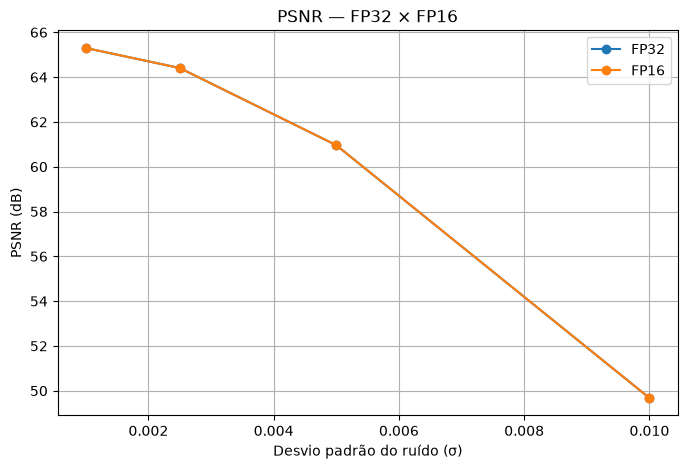

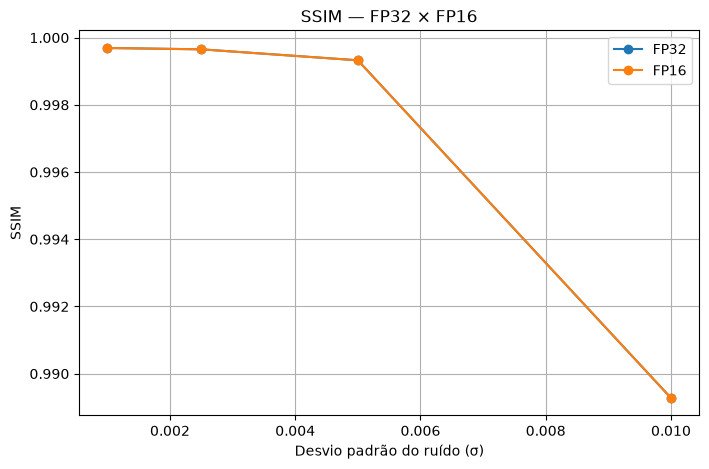

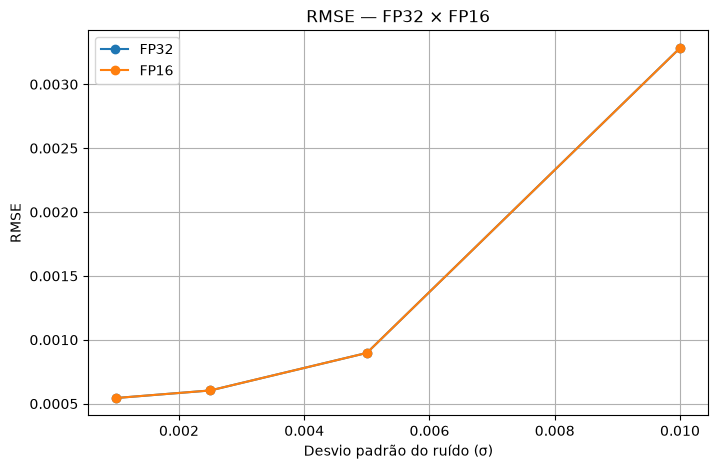

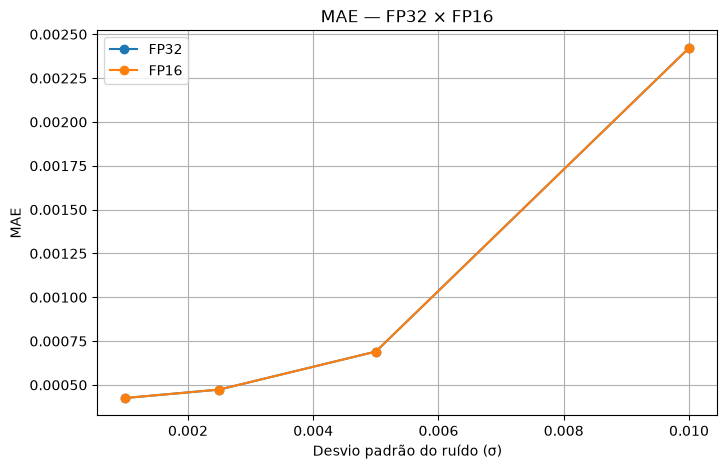

In [43]:
def plotar_fp32_fp16(
    df,
    metrica,
    ylabel,
    titulo
):
    plt.figure(figsize=(8, 5))

    plt.plot(
        df["sigma"],
        df[f"{metrica}_FP32"],
        marker="o",
        label="FP32"
    )

    plt.plot(
        df["sigma"],
        df[f"{metrica}_FP16"],
        marker="o",
        label="FP16"
    )

    plt.xlabel("Desvio padrão do ruído (σ)")
    plt.ylabel(ylabel)
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()


plotar_fp32_fp16(
    df_comparacao,
    "PSNR_Restaurada",
    "PSNR (dB)",
    "PSNR — FP32 × FP16"
)

plotar_fp32_fp16(
    df_comparacao,
    "SSIM_Restaurada",
    "SSIM",
    "SSIM — FP32 × FP16"
)

plotar_fp32_fp16(
    df_comparacao,
    "RMSE_Restaurada",
    "RMSE",
    "RMSE — FP32 × FP16"
)

plotar_fp32_fp16(
    df_comparacao,
    "MAE_Restaurada",
    "MAE",
    "MAE — FP32 × FP16"
)


## Comparação visual — Original × Ruidosa × FP32 × FP16

A mesma imagem (`índice 43`) é apresentada para todos os valores de `σ`.
A escala de visualização é determinada pela imagem original e mantida constante
nas quatro colunas de cada linha.


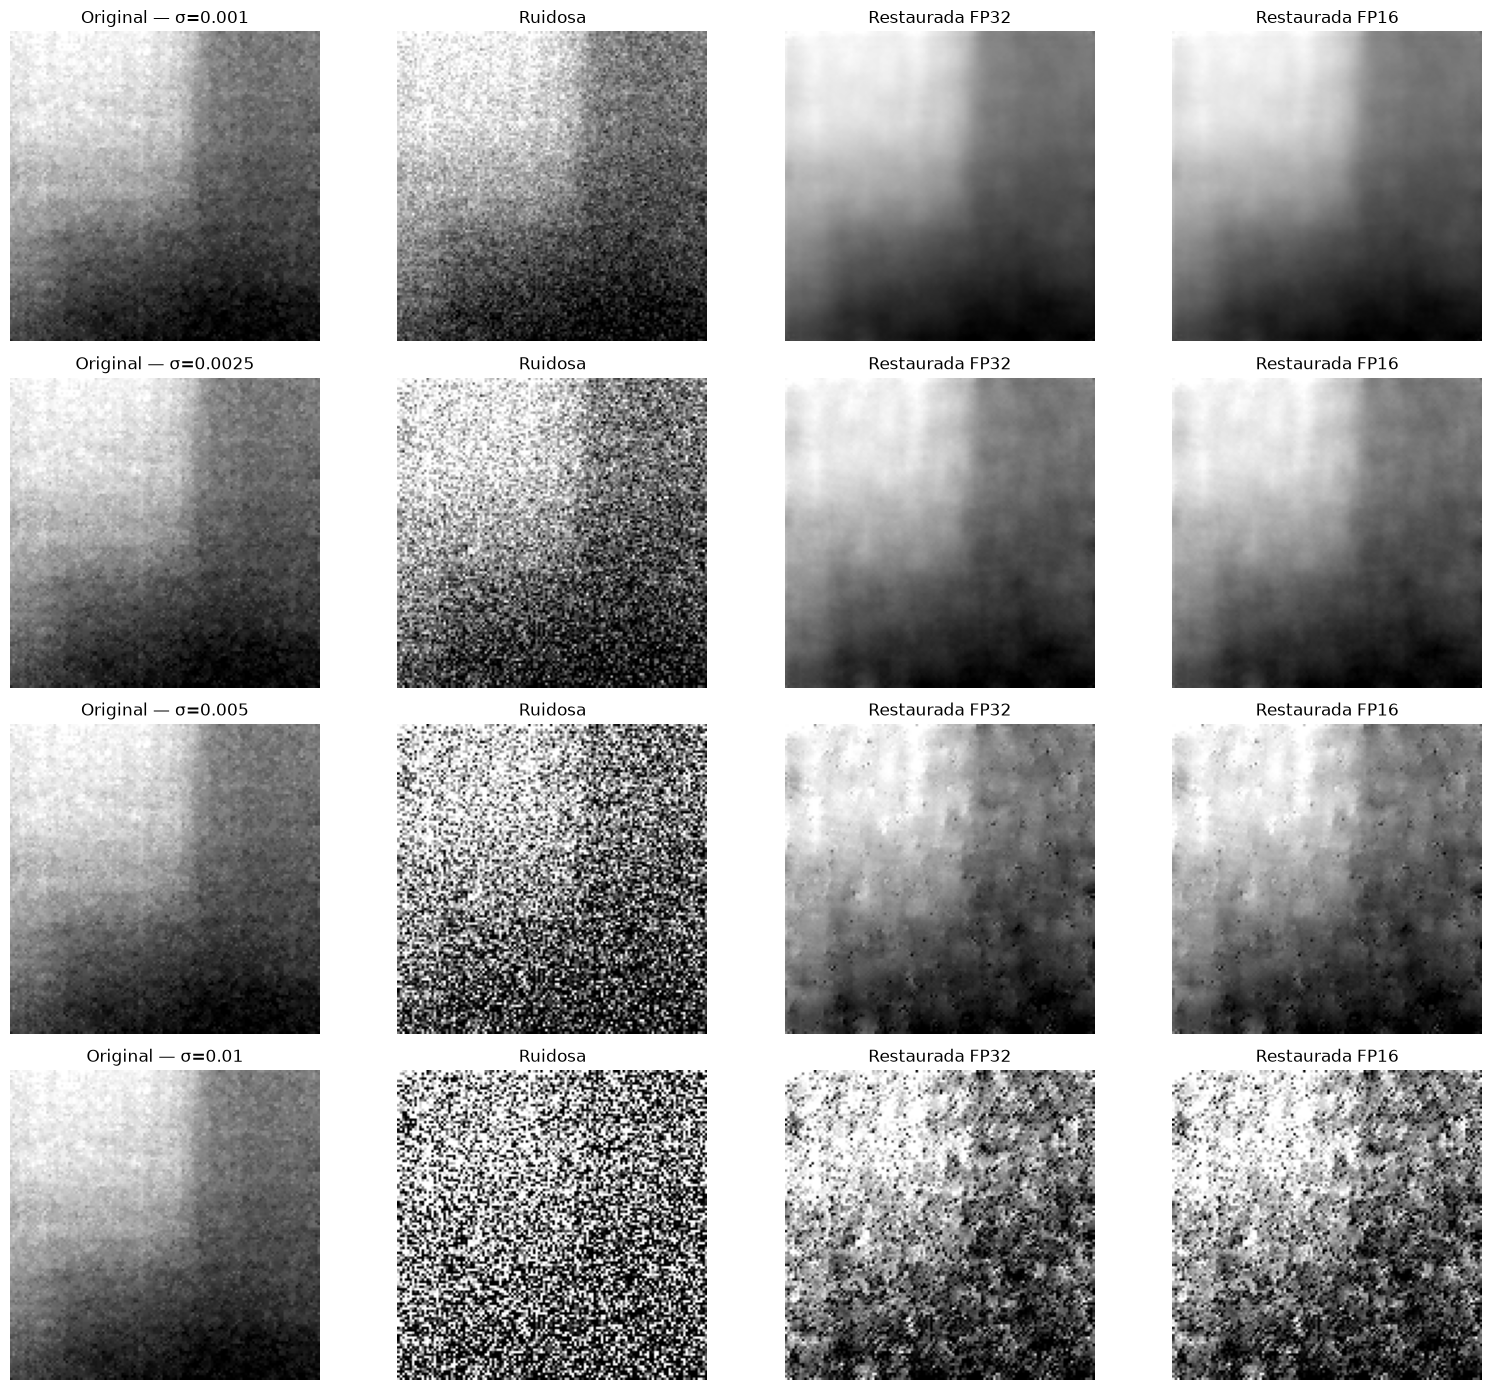

In [44]:
idx = INDICE_VISUAL

original = np.squeeze(
    x_test[idx]
)

vmin = np.percentile(
    original,
    1
)

vmax = np.percentile(
    original,
    99
)

plt.figure(
    figsize=(16, 3.5 * len(sigmas))
)

for linha, sigma_teste in enumerate(
    sigmas
):
    noisy = np.squeeze(
        resultados_imagens[
            sigma_teste
        ]["noisy"][idx]
    )

    restored_fp32 = np.squeeze(
        resultados_imagens[
            sigma_teste
        ]["restored"][idx]
    )

    restored_fp16 = np.squeeze(
        amostras_fp16[
            sigma_teste
        ]
    )

    imagens = [
        original,
        noisy,
        restored_fp32,
        restored_fp16
    ]

    titulos = [
        f"Original — σ={sigma_teste}",
        "Ruidosa",
        "Restaurada FP32",
        "Restaurada FP16"
    ]

    for coluna, (
        imagem,
        titulo
    ) in enumerate(
        zip(
            imagens,
            titulos
        )
    ):
        ax = plt.subplot(
            len(sigmas),
            4,
            linha * 4 + coluna + 1
        )

        plt.imshow(
            imagem,
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        plt.title(titulo)
        ax.axis("off")

plt.tight_layout()
plt.show()


## Interpretação

A comparação desta seção deve ser analisada em conjunto com o benchmark embarcado:

- redução do tamanho do artefato TFLite;
- latência e throughput FP32 × FP16 na Raspberry Pi Zero 2 W;
- memória e comportamento térmico;
- preservação das métricas PSNR, SSIM, RMSE e MAE.

A conclusão sobre a utilidade do FP16 deve considerar simultaneamente
**qualidade de restauração e custo computacional**.
